In [3]:
from src.utils import serialize_data, deserialize_data
from imblearn.over_sampling import RandomOverSampler
import yaml
import seaborn as sns
import pandas as pd

In [4]:
with open('../config/path.yaml', 'r') as f:
    path = yaml.safe_load(f)

X_train_prep_path = path['data_path']['data']['processed']['X_train_prep']
X_test_prep_path = path['data_path']['data']['processed']['X_test_prep']
X_valid_prep_path = path['data_path']['data']['processed']['X_valid_prep']
y_train_prep_path = path['data_path']['data']['processed']['y_train_prep']
X_train_ros_path = path['data_path']['data']['processed']['X_train_ros']
y_train_ros_path = path['data_path']['data']['processed']['y_train_ros']

X_TRAIN_PREP_PATH = X_train_prep_path
X_TEST_PREP_PATH = X_test_prep_path
X_VALID_PREP_PATH = X_valid_prep_path
Y_TRAIN_PREP_PATH = y_train_prep_path
X_TRAIN_ROS_PATH = X_train_ros_path
Y_TRAIN_ROS_PATH = y_train_ros_path

In [5]:
def random_oversampling(X_train: pd.DataFrame, y_train: pd.DataFrame):
    """
    Random over sampling to hanlde imbalance data

    Parameters:
        - X_train : input training data (type: pandas Dataframe)
        - y_train : output training data (type: pandas Dataframe)

    Return Values:
        - X_train_ros : input training data with random over sampling (type: pandas Dataframe)
        - y_train_ros : output training data with random over sampling (type: pandas Dataframe)
    """
    ros = RandomOverSampler()
    X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

    return X_train_ros, y_train_ros

In [6]:
X_train_prep = deserialize_data(X_TRAIN_PREP_PATH)
y_train_prep = deserialize_data(Y_TRAIN_PREP_PATH)

Succeed to deserialize data
Succeed to deserialize data


In [7]:
print(X_train_prep.columns)
print(X_train_prep.shape)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN',
       'home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'default_onfile_N',
       'default_onfile_Y'],
      dtype='object')
(25872, 26)


In [8]:
print(y_train_prep.shape)

(25872,)


In [9]:
ros = RandomOverSampler()

<Axes: xlabel='loan_status', ylabel='count'>

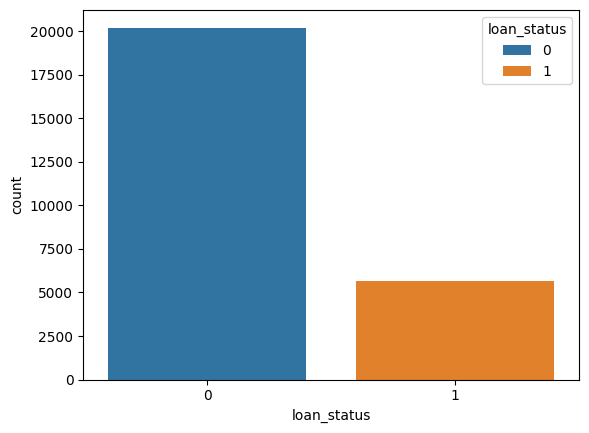

In [10]:
sns.countplot(x= y_train_prep, hue= y_train_prep)

In [11]:
# X_train_ros, y_train_ros = ros.fit_resample(X_train_prep, y_train_prep)
X_train_ros, y_train_ros = random_oversampling(X_train_prep, y_train_prep)

<Axes: xlabel='loan_status', ylabel='count'>

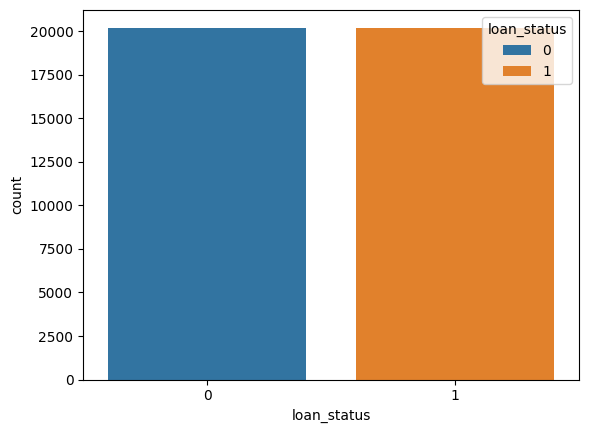

In [12]:
sns.countplot(x= y_train_ros, hue= y_train_ros)

In [13]:
serialize_data(X_train_ros, X_TRAIN_ROS_PATH)
serialize_data(y_train_ros, Y_TRAIN_ROS_PATH)

Succeed to serialize data
Succeed to serialize data
